# Problem 1: Gradient-based vs Grid-search System Identification in Sim2Sim (MuJoCo 3.5 SysID)

This notebook is structured to mirror the MuJoCo 3.5 System Identification (SysID) workflow (as in the official `sysid.ipynb`) while using a different toy system: a fully actuated 2-link planar arm with a fixed base.

You will compare a grid search baseline against a gradient-based least-squares method using the MuJoCo SysID toolbox where available. The notebook is boilerplate-only: you must complete the clearly marked TODOs.

## Learning Objectives
- Understand how trajectory-matching SysID is set up using MuJoCo 3.5's SysID utilities.
- Compare gradient-based optimization against brute-force grid search.
- See how identification quality affects rollout prediction and downstream control transfer.

Unknown parameters (2D):
1. distal link mass scale
2. joint damping scale (shared across both joints)

We keep it 2D so grid search remains feasible and we can visualize the loss surface.

## 1. Introduction
This is a sim2sim SysID problem. We generate "real" data from a hidden ground-truth simulator and identify parameters for a nominal simulator so that its rollouts match the real data under identical controls.

We aim to align with the MuJoCo 3.5 SysID workflow (residual definition, parameterization, least-squares solve), but with a different system than the official example.

## 2. Imports and Setup
- Allowed packages: `mujoco`, `numpy`, `matplotlib`.
- This cell sets deterministic seeds and basic plotting styles.
- Ensure MuJoCo >= 3.5 for the SysID toolbox. The first code cell installs packages from version pins defined in that same cell (edit the strings there to change versions).

In [34]:
# Version pins (edit only here) — installed via a temporary file for `pip install -r`
import os
import subprocess
import sys
import tempfile
from pathlib import Path

REQUIREMENTS_SYSID_NOTEBOOK = (
    "mujoco[sysid]>=3.5.0\n"
    "matplotlib>=3.7.0\n"
    "scipy>=1.10.0\n"
    "cma>=3.3,<4\n"
)
fd, _rp = tempfile.mkstemp(suffix="-pip-reqs.txt", text=True)
os.close(fd)
try:
    Path(_rp).write_text(REQUIREMENTS_SYSID_NOTEBOOK, encoding="utf-8")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", _rp])
finally:
    try:
        os.unlink(_rp)
    except OSError:
        pass

import scipy.optimize


from typing import Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

import mujoco
from mujoco import MjModel, MjData, mj_step, mj_forward

try:
    from mujoco import sysid as mj_sysid  # MuJoCo 3.5 SysID toolbox
    HAS_SYSID = True
except Exception:
    HAS_SYSID = False

# Deterministic seeds
SEED = 123

np.set_printoptions(precision=4, suppress=True)
mpl.rcParams['figure.figsize'] = (8, 4)
mpl.rcParams['axes.grid'] = True
mpl.rcParams['lines.linewidth'] = 2

def mj_version_ok(major=3, minor=5):
    v = getattr(mujoco, '__version__', '0.0.0')
    parts = [int(x) for x in v.split('.')[:2]] if isinstance(v, str) else [3,5]
    return (parts[0] > major) or (parts[0] == major and parts[1] >= minor)

print('MuJoCo version:', getattr(mujoco, '__version__', 'unknown'))
print('HAS_SYSID:', HAS_SYSID)
if not mj_version_ok(3,5):
    print('Warning: MuJoCo >= 3.5 is recommended for the SysID toolbox.')
# Enforce presence of the SysID toolbox for this assignment
if not HAS_SYSID:
   raise ImportError('MuJoCo sysid toolbox not found. Please install mujoco>=3.5.')

MuJoCo version: 3.8.0
HAS_SYSID: True


In [35]:
# (Optional) SysID API primer — uncomment to inspect available utilities
print('mujoco.sysid contents:', dir(mj_sysid))
if hasattr(mj_sysid, '__doc__'):
    print('mujoco.sysid doc:')
    print(mj_sysid.__doc__)
pass

mujoco.sysid contents: ['BuildModelFn', 'CustomRolloutFn', 'InertiaType', 'ModelSequences', 'ModifyResidualFn', 'Parameter', 'ParameterDict', 'SignalTransform', 'SignalType', 'SystemTrajectory', 'TimeSeries', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_bias', 'apply_body_inertia', 'apply_delay', 'apply_delayed_ts_window', 'apply_dgain', 'apply_gain', 'apply_param_modifiers', 'apply_param_modifiers_spec', 'apply_pdgain', 'apply_pgain', 'apply_resample_and_delay', 'body_inertia_param', 'build_residual_fn', 'calculate_intervals', 'construct_ts_from_defaults', 'create_initial_state', 'default_report', 'get_sensor_indices', 'model_modifier', 'model_residual', 'normalize_residual', 'optimize', 'parameter', 'remove_visuals', 'render_rollout', 'report', 'residual', 'save_results', 'signal_modifier', 'sysid_rollout', 'weighted_diff']
mujoco.sysid doc:
System identification toolbox.


## 3. Define MuJoCo Models (2-Link Planar Arm)
Programmatically generate MJCF for a 2-link planar arm with gravity and torque actuators at both joints.
Unknowns: distal link mass scale and joint-damping scale (shared). Link lengths and base masses/damping are fixed.

In [36]:
ARM_PARAMS = {
    'L1': 0.35,
    'L2': 0.30,
    'M1': 0.25,
    'M2_BASE': 0.20,
    'J_DAMP_BASE': 0.05,
}

def make_arm_xml(mass_scale: float = 1.0, damping_scale: float = 1.0, dt: float = 0.005) -> str:
    assert mass_scale > 0 and damping_scale > 0
    L1, L2 = ARM_PARAMS['L1'], ARM_PARAMS['L2']
    M1 = ARM_PARAMS['M1']
    M2 = ARM_PARAMS['M2_BASE'] * float(mass_scale)
    JD = ARM_PARAMS['J_DAMP_BASE'] * float(damping_scale)
    return f"""
<mujoco model='two_link_planar'>
  <compiler coordinate='local' angle='radian' />
  <option timestep='{dt:.6f}' gravity='0 0 -9.81' integrator='RK4' />
  <default>
    <joint limited='false' damping='{JD:.6f}' armature='0.0' stiffness='0.0' />
    <geom type='capsule' size='0.025' rgba='0.5 0.6 0.7 1' />
    <motor ctrllimited='true' ctrlrange='-5 5' />
  </default>
  <worldbody>
    <body name='link1' pos='0 0 0'>
      <inertial mass='{M1:.6f}' diaginertia='0.001 0.001 0.001' pos='{L1/2:.6f} 0 0'/>
      <joint name='joint1' type='hinge' axis='0 0 1' pos='0 0 0'/>
      <geom name='g1' fromto='0 0 0 {L1:.6f} 0 0'/>
      <body name='link2' pos='{L1:.6f} 0 0'>
        <inertial mass='{M2:.6f}' diaginertia='0.001 0.001 0.001' pos='{L2/2:.6f} 0 0'/>
        <joint name='joint2' type='hinge' axis='0 0 1' pos='0 0 0'/>
        <geom name='g2' fromto='0 0 0 {L2:.6f} 0 0' rgba='0.8 0.5 0.4 1'/>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor name='u1' joint='joint1' gear='1'/>
    <motor name='u2' joint='joint2' gear='1'/>
  </actuator>
</mujoco>
"""

def load_model_from_params(mass_scale: float, damping_scale: float, dt: float = 0.005) -> Tuple[MjModel, MjData]:
    xml = make_arm_xml(mass_scale=mass_scale, damping_scale=damping_scale, dt=dt)
    model = MjModel.from_xml_string(xml)
    data = MjData(model)
    return model, data

def get_dims(model: MjModel) -> Tuple[int, int, int]:
    return model.nq, model.nv, model.nu

print('Model builder ready (SysID style).')

Model builder ready (SysID style).


## 4. Simulation and Plotting Utilities
These helpers mirror a typical SysID workflow: consistent rollout, error metrics, plotting. They are fully implemented for you.

In [37]:
def set_model_parameters(model_template: MjModel, theta: np.ndarray, dt: Optional[float] = None) -> Tuple[MjModel, MjData]:
    """Autograder API: returns a fresh model/data with parameters from theta.

    This version rebuilds from XML (simple, robust). In your gradient-based TODO,
    you may additionally demonstrate use of mujoco.sysid parameter utilities if available.
    """
    theta = np.asarray(theta, dtype=float).reshape(-1)
    assert theta.size == 2, 'theta must be [mass_scale, damping_scale]'
    mass_scale, damping_scale = float(theta[0]), float(theta[1])
    if dt is None:
        dt = float(model_template.opt.timestep)
    xml = make_arm_xml(mass_scale=mass_scale, damping_scale=damping_scale, dt=dt)
    model = MjModel.from_xml_string(xml)
    data = MjData(model)
    return model, data

def reset_state(model: MjModel, data: MjData, qpos0: np.ndarray, qvel0: np.ndarray) -> None:
    qpos0 = np.asarray(qpos0, dtype=float)
    qvel0 = np.asarray(qvel0, dtype=float)
    nq, nv, _ = get_dims(model)
    assert qpos0.shape == (nq,) and qvel0.shape == (nv,)
    data.qpos[:], data.qvel[:] = qpos0, qvel0
    mj_forward(model, data)

def rollout_trajectory(model: MjModel, qpos0: np.ndarray, qvel0: np.ndarray, ctrl: np.ndarray, T: Optional[int] = None, record: bool = True) -> Dict[str, Any]:
    ctrl = np.asarray(ctrl, dtype=float)
    if T is None:
        T = ctrl.shape[0]
    nq, nv, nu = get_dims(model)
    assert ctrl.shape == (T, nu)
    data = MjData(model)
    reset_state(model, data, qpos0, qvel0)
    qpos_traj = np.zeros((T, nq)) if record else None
    qvel_traj = np.zeros((T, nv)) if record else None
    for t in range(T):
        data.ctrl[:] = ctrl[t]
        mj_step(model, data)
        if record:
            qpos_traj[t] = data.qpos
            qvel_traj[t] = data.qvel
    return {
        'qpos': qpos_traj, 'qvel': qvel_traj, 'ctrl': ctrl.copy(),
        'qpos0': np.asarray(qpos0).copy(), 'qvel0': np.asarray(qvel0).copy(),
        'dt': float(model.opt.timestep), 'T': int(T)
    }

def plot_traj(traj: Dict[str, Any], title: str = 'Trajectory') -> None:
    T = traj['T']
    tvec = np.arange(T) * traj['dt']
    fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    axs[0].plot(tvec, traj['qpos'])
    axs[0].set_ylabel('qpos [rad]')
    axs[1].plot(tvec, traj['qvel'])
    axs[1].set_ylabel('qvel [rad/s]')
    axs[2].plot(tvec, traj['ctrl'])
    axs[2].set_ylabel('tau [Nm]')
    axs[2].set_xlabel('time [s]')
    fig.suptitle(title)
    plt.show()

def plot_compare_traj(real: Dict[str, Any], sim: Dict[str, Any], suptitle: str = 'Real vs Sim') -> None:
    assert real['T'] == sim['T']
    tvec = np.arange(real['T']) * real['dt']
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axs[0].plot(tvec, real['qpos'], '--', label='real')
    axs[0].plot(tvec, sim['qpos'], '-', label='sim')
    axs[0].set_ylabel('qpos')
    axs[0].legend()
    axs[1].plot(tvec, real['qvel'], '--', label='real')
    axs[1].plot(tvec, sim['qvel'], '-', label='sim')
    axs[1].set_ylabel('qvel')
    axs[1].set_xlabel('time [s]')
    axs[1].legend()
    fig.suptitle(suptitle)
    plt.show()

def rollout_error(real: Dict[str, Any], sim: Dict[str, Any], wq: float = 1.0, wv: float = 0.1) -> float:
    dq = real['qpos'] - sim['qpos']
    dv = real['qvel'] - sim['qvel']
    return float(wq * np.mean(dq**2) + wv * np.mean(dv**2))

print('Simulation utilities ready.')

Simulation utilities ready.


## 5. Generate Synthetic "Real" Dataset
Hidden ground-truth parameters produce multiple rollouts with diverse initial conditions and rich excitation.
Split into train/test. Parameters are not secret; the learning goal is the identification process.

Dataset: 6 train / 3 test


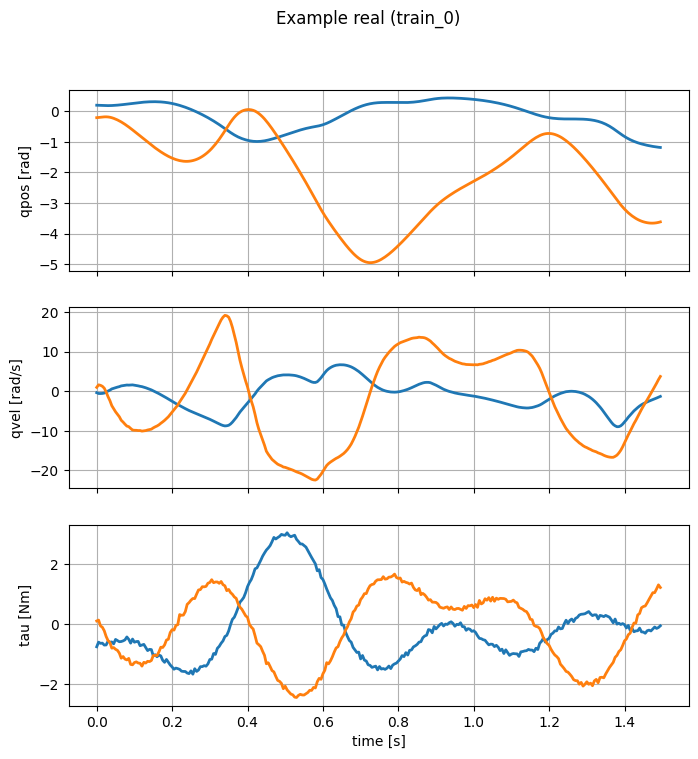

In [38]:
THETA_TRUE = np.array([1.35, 1.80], dtype=float)   # [mass_scale, damping_scale]
THETA_NOMINAL = np.array([0.75, 0.60], dtype=float)

DT = 0.005
HORIZON_S = 1.5
T = int(HORIZON_S / DT)
N_TRAIN, N_TEST = 6, 3

def make_excitation(T: int, dt: float, rng: np.random.RandomState, nu: int = 2, base_amp: float = 1.25, noise_std: float = 0.05) -> np.ndarray:
    t = np.arange(T) * dt
    freqs = np.array([1.0, 1.7, 2.5])
    ctrl = np.zeros((T, nu))
    for j in range(nu):
        phases = rng.uniform(0, 2*np.pi, size=freqs.shape)
        amps = base_amp * (0.6 + 0.4 * rng.rand(freqs.size))
        sig = sum(a * np.sin(2*np.pi*f*t + p) for a, f, p in zip(amps, freqs, phases))
        ctrl[:, j] = sig
    ctrl += noise_std * rng.randn(T, nu)
    return np.clip(ctrl, -5.0, 5.0)

def generate_dataset(theta_true: np.ndarray, n_train: int = 6, n_test: int = 3, dt: float = DT, T: int = T, seed: int = SEED) -> Dict[str, Any]:
    rng_local = np.random.RandomState(seed)
    model_real, _ = load_model_from_params(theta_true[0], theta_true[1], dt=dt)
    nq, nv, nu = get_dims(model_real)
    def sample_ic():
        return (rng_local.uniform(-0.5, 0.5, size=(nq,)), rng_local.uniform(-0.1, 0.1, size=(nv,)))
    def make_traj(name):
        q0, v0 = sample_ic()
        ctrl = make_excitation(T, dt, rng_local, nu)
        real = rollout_trajectory(model_real, q0, v0, ctrl, T=T)
        real['name'] = name
        return real
    train = [make_traj(f'train_{i}') for i in range(n_train)]
    test  = [make_traj(f'test_{i}')  for i in range(n_test)]
    return {'train': train, 'test': test, 'dt': dt, 'T': T, 'nq': nq, 'nv': nv, 'nu': nu}

dataset = generate_dataset(THETA_TRUE, N_TRAIN, N_TEST, dt=DT, T=T, seed=SEED)
print(f"Dataset: {len(dataset['train'])} train / {len(dataset['test'])} test")
plot_traj(dataset['train'][0], title='Example real (train_0)')

## 6. Baseline Nominal Mismatch
Roll out a nominal model with incorrect parameters on one training trajectory and visualize mismatch before SysID.

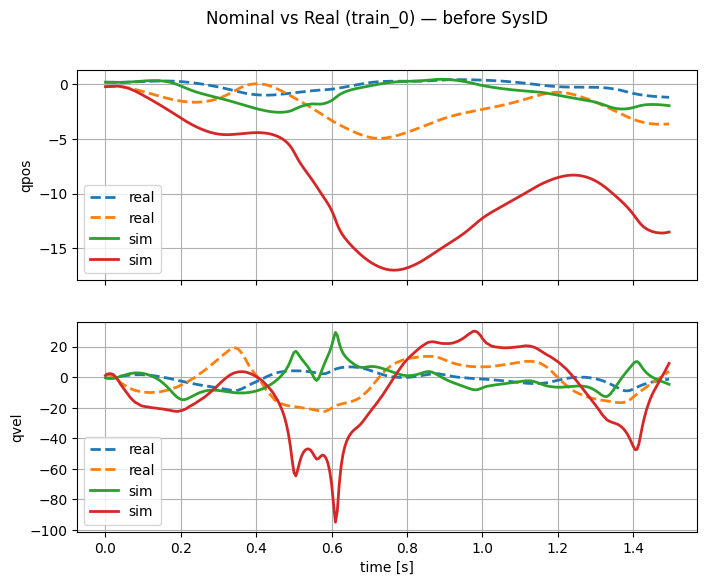

Nominal pre-SysID rollout error: 49.96156925017857


In [39]:
model_nom, _ = load_model_from_params(THETA_NOMINAL[0], THETA_NOMINAL[1], dt=DT)
ex = dataset['train'][0]
sim_nom = rollout_trajectory(model_nom, ex['qpos0'], ex['qvel0'], ex['ctrl'], T=ex['T'])
plot_compare_traj(ex, sim_nom, suptitle='Nominal vs Real (train_0) — before SysID')
print('Nominal pre-SysID rollout error:', rollout_error(ex, sim_nom))

## 7. TODO 1: Trajectory Loss (SysID-style residual)
Implement `trajectory_loss(theta, dataset, ...)` computing a weighted MSE over qpos and qvel between real and simulated trajectories on the specified split.

This mirrors the residual definition in MuJoCo SysID (sum of residuals across all timesteps/trajectories). Use `set_model_parameters` and `rollout_trajectory`. Optionally, return per-trajectory losses.

Autograder API: `trajectory_loss(...)`.

In [40]:
# =========================
# TODO: Student code here
# =========================
def trajectory_loss(theta: np.ndarray, dataset: Dict[str, Any], split: str = 'train', wq: float = 1.0, wv: float = 0.1, bounds: Optional[Tuple[Tuple[float, float], Tuple[float, float]]] = ((0.2, 0.2), (3.0, 3.0)), return_per_traj: bool = False) -> Any:
    """Compute weighted trajectory-matching loss over qpos/qvel.

    Steps:
    1) Clamp/check theta within bounds;
    2) Build model via set_model_parameters;
    3) For each trajectory in dataset[split], simulate with same IC + ctrl;
    4) Accumulate weighted MSE and average across trajectories.
    """

    # 1) Clamp theta within bounds
    lo = np.array([bounds[0][0], bounds[0][1]])
    hi = np.array([bounds[1][0], bounds[1][1]])
    theta = np.clip(theta, lo, hi)

    # 2) Build model
    model_template, _ = load_model_from_params(1.0, 1.0)  # dummy for set_model_parameters
    model, _ = set_model_parameters(model_template, theta)

    # 3) Loop over trajectories
    losses = []
    for traj in dataset[split]:
        sim = rollout_trajectory(model, traj['qpos0'], traj['qvel0'], traj['ctrl'], T=traj['T'])
        loss = rollout_error(traj, sim, wq=wq, wv=wv)
        losses.append(loss)

    # 4) Average
    per_traj = np.array(losses)
    total = float(np.mean(per_traj))

    return (total, per_traj) if return_per_traj else total


# Quick scaffold test (enable after implementing):
try:
    loss_true = trajectory_loss(THETA_TRUE, dataset, split='train')
    loss_nom  = trajectory_loss(THETA_NOMINAL, dataset, split='train')
    print('loss_true  =', loss_true)
    print('loss_nom   =', loss_nom)
    assert loss_true <= loss_nom + 1e-6
except NotImplementedError:
    print('Implement trajectory_loss to run the check.')

loss_true  = 0.0
loss_nom   = 28.433199856494834


## 8. TODO 2: Grid Search Baseline
Define a 2D grid over (mass_scale, damping_scale), evaluate `trajectory_loss` on the training set, and return the best parameter pair along with the loss surface for visualization.

Autograder API: `run_grid_search(...)`.

Grid row 1/25 done
Grid row 2/25 done
Grid row 3/25 done
Grid row 4/25 done
Grid row 5/25 done
Grid row 6/25 done
Grid row 7/25 done
Grid row 8/25 done
Grid row 9/25 done
Grid row 10/25 done
Grid row 11/25 done
Grid row 12/25 done
Grid row 13/25 done
Grid row 14/25 done
Grid row 15/25 done
Grid row 16/25 done
Grid row 17/25 done
Grid row 18/25 done
Grid row 19/25 done
Grid row 20/25 done
Grid row 21/25 done
Grid row 22/25 done
Grid row 23/25 done
Grid row 24/25 done
Grid row 25/25 done


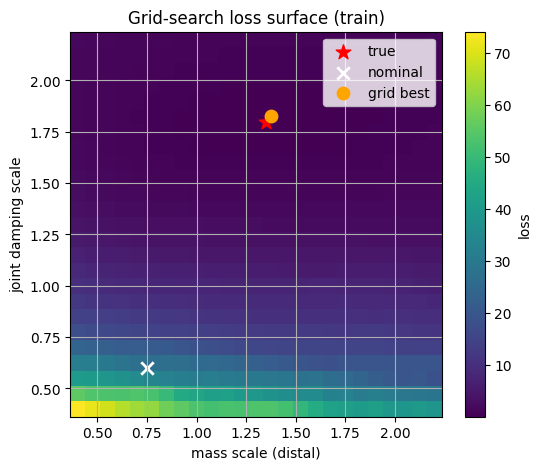

In [41]:
# =========================
# TODO: Student code here
# =========================
def run_grid_search(theta_bounds: Tuple[Tuple[float, float], Tuple[float, float]], dataset: Dict[str, Any], split: str = 'train', grid_sizes: Tuple[int, int] = (21, 21), wq: float = 1.0, wv: float = 0.1, verbose: bool = True) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Grid search over mass and damping scales.

    Returns: best_theta, mass_grid, damp_grid, loss_grid
    """
    # Build 1D grids for each parameter
    mass_grid = np.linspace(theta_bounds[0][0], theta_bounds[1][0], grid_sizes[0])
    damp_grid = np.linspace(theta_bounds[0][1], theta_bounds[1][1], grid_sizes[1])

    # 2D loss surface
    loss_grid = np.zeros((grid_sizes[0], grid_sizes[1]))

    for i, am in enumerate(mass_grid):
        for j, ab in enumerate(damp_grid):
            loss_grid[i, j] = trajectory_loss(
                [am, ab], dataset, split=split, wq=wq, wv=wv
            )
        if verbose:
            print(f'Grid row {i+1}/{grid_sizes[0]} done')

    # Find best
    best_idx = np.unravel_index(np.argmin(loss_grid), loss_grid.shape)
    best_theta = np.array([mass_grid[best_idx[0]], damp_grid[best_idx[1]]])

    return best_theta, mass_grid, damp_grid, loss_grid

# Visualization scaffold (enable after implementing):
try:
    bounds = ((0.4, 0.4), (2.2, 2.2))
    best_theta, mgrid, dgrid, L = run_grid_search(bounds, dataset, split='train', grid_sizes=(25, 25))
    M, D = np.meshgrid(mgrid, dgrid, indexing='ij')
    plt.figure(figsize=(6,5))
    pcm = plt.pcolormesh(M, D, L, shading='auto', cmap=cm.viridis)
    plt.scatter([THETA_TRUE[0]], [THETA_TRUE[1]], c='r', marker='*', s=120, label='true')
    plt.scatter([THETA_NOMINAL[0]], [THETA_NOMINAL[1]], c='w', marker='x', s=80, label='nominal')
    plt.scatter([best_theta[0]], [best_theta[1]], c='orange', marker='o', s=80, label='grid best')
    plt.xlabel('mass scale (distal)')
    plt.ylabel('joint damping scale')
    plt.title('Grid-search loss surface (train)')
    plt.colorbar(pcm, label='loss')
    plt.legend()
    plt.show()
except NotImplementedError:
    print('Implement run_grid_search to visualize loss surface.')

## 9. TODO 3: Gradient-based SysID (MuJoCo 3.5 SysID)
Implement `run_gradient_sysid` to perform a least-squares identification starting from the nominal parameters using the MuJoCo SysID toolbox (no external optimizers).

Tips (SysID-flavored):
- Construct a residual vector concatenating qpos and qvel errors across timesteps/trajectories.
- Enforce positivity via bounds.
- Return identified parameters and diagnostics.

Autograder API: `run_gradient_sysid(...)`.

In [56]:
# =========================
# TODO: Student code here
# =========================
def run_gradient_sysid(theta_init: np.ndarray, dataset: Dict[str, Any], split: str = 'train', bounds: Tuple[Tuple[float, float], Tuple[float, float]] = ((0.2, 0.2), (3.0, 3.0)), options: Optional[Dict[str, Any]] = None) -> Tuple[np.ndarray, Dict[str, Any]]:
    """Gradient-based SysID using MuJoCo SysID toolbox (no external optimizers).

    Returns: theta_hat, info dict (e.g., {'success': bool, 'nfev': int, 'final_loss': float}).
    """
    # Suggested workflow (outline):
    # 1) Validate/clip theta_init within bounds.
    # 2) Define a residual function r(theta) that concatenates weighted qpos/qvel errors
    #    across all trajectories and timesteps (SysID-style residual).
    # 3) Use mujoco.sysid utilities for parameterization and Jacobians (no external optimizers).
    # 4) Return (theta_hat, info).
    # Example (pseudo, to be replaced with your implementation):
    # if HAS_SYSID:
    #     # Build problem using mj_sysid (e.g., parameter spec + residual builder).
    #     # Solve with the toolbox's least-squares support.
    #     pass
    # elif HAS_SCIPY:
    #     # Solve using the toolbox's least-squares support and report diagnostics.
    #     pass
    # Placeholder to avoid lint warnings about unused variables in the stub

    from scipy.optimize import minimize

    # 1) Clip theta_init within bounds
    lo = np.array([bounds[0][0], bounds[0][1]])
    hi = np.array([bounds[1][0], bounds[1][1]])
    theta_init = np.clip(np.asarray(theta_init, dtype=float), lo, hi)

    loss_history = []
    nfev = [0]

    def objective(theta):
        loss = trajectory_loss(theta, dataset, split=split, wq=1.0, wv=0.1)
        loss_history.append(float(loss))
        nfev[0] += 1
        return loss

    scipy_bounds = [
        (bounds[0][0], bounds[1][0]),
        (bounds[0][1], bounds[1][1]),
    ]

    result = minimize(   # ← use minimize directly, not scipy.optimize.minimize
        objective,
        theta_init,
        method='L-BFGS-B',
        bounds=scipy_bounds,
        options=options or {
            'ftol': 1e-12,
            'gtol': 1e-8,
            'maxiter': 300,
            'eps': 0.05,   # ← this is the key fix
        }
    )

    info = {
        'success': result.success,
        'nfev': nfev[0],
        'final_loss': float(result.fun),
        'loss_history': loss_history,
        'message': result.message
    }

    return result.x, info


# Example usage scaffold (enable after implementing):
try:
    theta_g, info_g = run_gradient_sysid(THETA_NOMINAL, dataset, split='train', bounds=((0.4, 0.4), (2.2, 2.2)))
    print('Gradient-based theta:', theta_g)
    print('Info:', info_g)
except NotImplementedError:
    print('Implement run_gradient_sysid to run this cell.')

Gradient-based theta: [1.3224 1.7726]
Info: {'success': True, 'nfev': 171, 'final_loss': 0.004877156851581334, 'loss_history': [28.433199856494834, 27.936169196546427, 24.92237408566349, 0.920232162830577, 0.8873372983360955, 0.8500905718268182, 0.8327404862075154, 0.8677532150469625, 0.7556988749632856, 0.4418760093750545, 0.4779577725617758, 0.5282835174881079, 1.268468161554469, 1.2530620347910328, 0.9430502585552208, 0.09502474074572718, 0.12621153233166624, 0.09416102656149361, 0.5088088984518205, 0.4688523300873901, 0.35627821628811884, 0.04436366107151474, 0.06388273330549343, 0.0211863287612936, 0.011827228545196933, 0.004362506231768866, 0.01829214616622025, 0.004879973291344974, 0.0060346161906972414, 0.0047812922629434, 0.005661288926000027, 0.005686875777160331, 0.0055096953980772224, 0.004901561342802883, 0.006010678145342441, 0.004811298338464997, 0.004880784244577412, 0.00603291366112426, 0.0047832363274363165, 0.004879973291344974, 0.0060346161906972414, 0.0047812922629

In [57]:
# cma: installed in the first setup cell
import cma
import time

def run_cmaes_sysid(theta_init, dataset, split='train',
                    bounds=((0.4, 0.4), (2.2, 2.2)), sigma0=0.3,
                    maxfevals=500, verbose=True):
    """
    CMA-ES based SysID. Replaces grid search with a scalable
    sampling-based optimizer.

    Args:
        theta_init: starting point [mass_scale, damping_scale]
        sigma0: initial step size (spread of search)
        maxfevals: max function evaluations budget
    Returns:
        best_theta, info dict
    """
    theta_init = np.asarray(theta_init, dtype=float)

    lo = [bounds[0][0], bounds[0][1]]
    hi = [bounds[1][0], bounds[1][1]]

    loss_history = []
    nfev = [0]
    start_time = time.time()

    def objective(theta):
        # CMA-ES minimizes, so just return loss directly
        loss = trajectory_loss(theta, dataset, split=split, wq=1.0, wv=0.1)
        loss_history.append(float(loss))
        nfev[0] += 1
        return loss

    # CMA-ES options
    cma_options = {
        'bounds': [lo, hi],          # box constraints
        'maxfevals': maxfevals,       # budget
        'tolx': 1e-6,                 # stop if step size tiny
        'tolfun': 1e-8,              # stop if loss change tiny
        'verbose': -9 if not verbose else 3,  # quiet unless verbose
        'seed': SEED,
    }

    # Run CMA-ES
    es = cma.CMAEvolutionStrategy(theta_init, sigma0, cma_options)

    while not es.stop():
        solutions = es.ask()          # sample candidate solutions
        fitnesses = [objective(x) for x in solutions]  # evaluate each
        es.tell(solutions, fitnesses) # update distribution
        if verbose:
            es.disp()

    result = es.result
    elapsed = time.time() - start_time

    info = {
        'success': True,
        'nfev': nfev[0],
        'final_loss': float(result.fbest),
        'loss_history': loss_history,
        'elapsed_s': elapsed,
    }

    return np.array(result.xbest), info

## 10. Compare Results
Report nominal, grid-search, and gradient-based parameter estimates. Compare train/test losses. Visualize rollouts and (optionally) PD tracking transfer on held-out data.

Grid row 1/21 done
Grid row 2/21 done
Grid row 3/21 done
Grid row 4/21 done
Grid row 5/21 done
Grid row 6/21 done
Grid row 7/21 done
Grid row 8/21 done
Grid row 9/21 done
Grid row 10/21 done
Grid row 11/21 done
Grid row 12/21 done
Grid row 13/21 done
Grid row 14/21 done
Grid row 15/21 done
Grid row 16/21 done
Grid row 17/21 done
Grid row 18/21 done
Grid row 19/21 done
Grid row 20/21 done
Grid row 21/21 done
--- Parameter estimates ---
     nominal theta = [0.75 0.6 ], |error| = [0.6 1.2]
        grid theta = [1.39 1.84], |error| = [0.04 0.04]
    gradient theta = [1.3224 1.7726], |error| = [0.0276 0.0274]
---Rollout errors ---
nominal  train=28.4332, test=28.8865
grid     train=0.0097, test=0.0081
gradient train=0.0049, test=0.0042


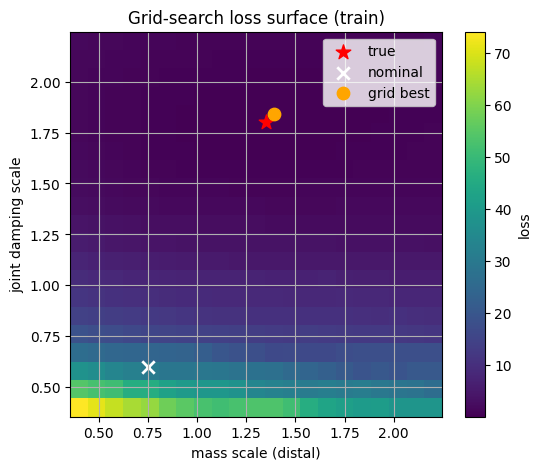

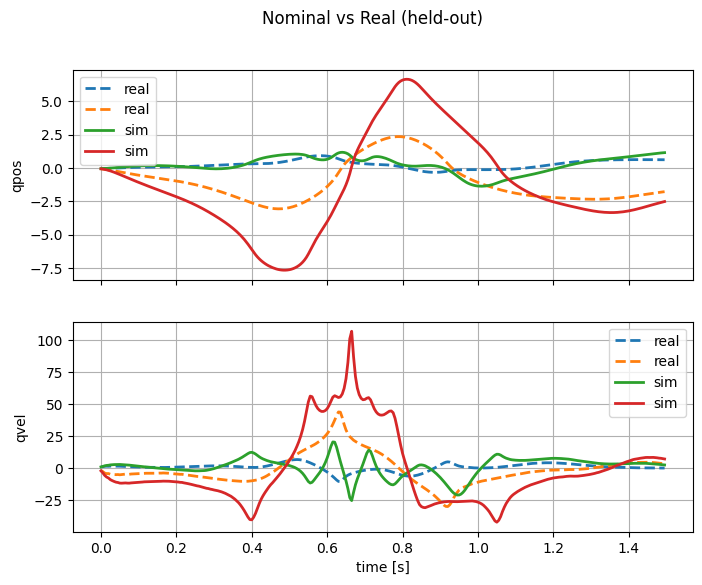

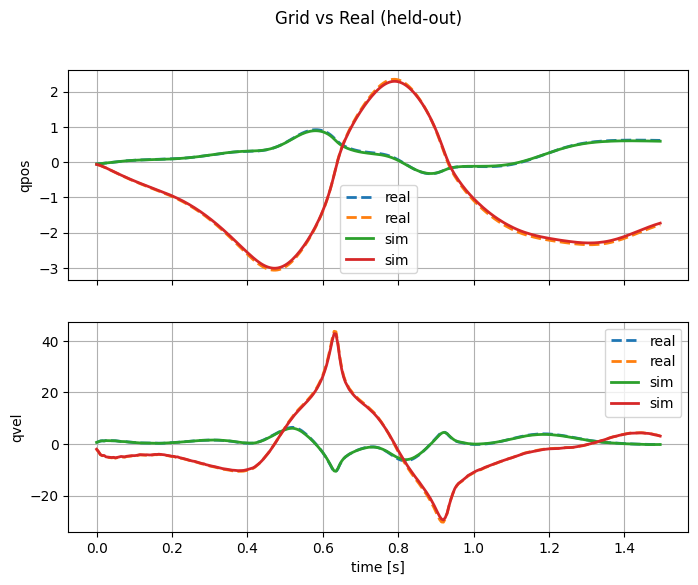

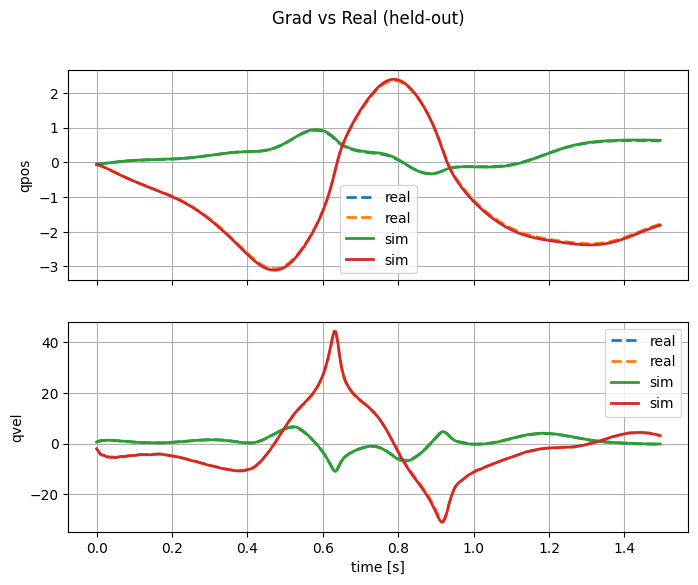

Comparison scaffold ready.


In [58]:
def evaluate_params(theta: np.ndarray, dataset: Dict[str, Any]) -> Tuple[float, float]:
    tr = trajectory_loss(theta, dataset, split='train')
    te = trajectory_loss(theta, dataset, split='test')
    return float(tr), float(te)

def print_param_summary(name: str, theta: np.ndarray, theta_true: np.ndarray) -> None:
    err = np.abs(theta - theta_true)
    print(f'{name:>12} theta = {theta}, |error| = {err}')

have_core = True
try:
    _ = trajectory_loss(THETA_NOMINAL, dataset, split='train')
except NotImplementedError:
    have_core = False

if not have_core:
    print('Complete the TODOs (trajectory_loss, run_grid_search, run_gradient_sysid) to run this section.')
else:
    tr_nom, te_nom = evaluate_params(THETA_NOMINAL, dataset)
    try:
        bounds = ((0.4, 0.4), (2.2, 2.2))
        theta_grid, mgrid, dgrid, L = run_grid_search(bounds, dataset, split='train', grid_sizes=(21, 21))
        tr_grid, te_grid = evaluate_params(theta_grid, dataset)
    except NotImplementedError:
        theta_grid, tr_grid, te_grid, L = None, None, None, None
    try:
        theta_grad, info_grad = run_gradient_sysid(THETA_NOMINAL, dataset, split='train', bounds=((0.4, 0.4), (2.2, 2.2)))
        tr_grad, te_grad = evaluate_params(theta_grad, dataset)
    except NotImplementedError:
        theta_grad, tr_grad, te_grad, info_grad = None, None, None, None

    print('--- Parameter estimates ---')
    print_param_summary('nominal', THETA_NOMINAL, THETA_TRUE)
    if theta_grid is not None: print_param_summary('grid', theta_grid, THETA_TRUE)
    else: print('grid        pending (implement run_grid_search).')
    if theta_grad is not None: print_param_summary('gradient', theta_grad, THETA_TRUE)
    else: print('gradient    pending (implement run_gradient_sysid).')

    print('---Rollout errors ---')
    print(f'nominal  train={tr_nom:.4f}, test={te_nom:.4f}')
    if tr_grid is not None: print(f'grid     train={tr_grid:.4f}, test={te_grid:.4f}')
    if tr_grad is not None: print(f'gradient train={tr_grad:.4f}, test={te_grad:.4f}')

    if L is not None:
        M, D = np.meshgrid(mgrid, dgrid, indexing='ij')
        plt.figure(figsize=(6,5))
        pcm = plt.pcolormesh(M, D, L, shading='auto', cmap=cm.viridis)
        plt.scatter([THETA_TRUE[0]], [THETA_TRUE[1]], c='r', marker='*', s=120, label='true')
        plt.scatter([THETA_NOMINAL[0]], [THETA_NOMINAL[1]], c='w', marker='x', s=80, label='nominal')
        if theta_grid is not None:
            plt.scatter([theta_grid[0]], [theta_grid[1]], c='orange', marker='o', s=80, label='grid best')
        plt.xlabel('mass scale (distal)')
        plt.ylabel('joint damping scale')
        plt.title('Grid-search loss surface (train)')
        plt.colorbar(pcm, label='loss')
        plt.legend()
        plt.show()

    heldout = dataset['test'][0]
    def rollout_from_theta(theta_hat, name):
        if theta_hat is None: return
        model_hat, _ = load_model_from_params(theta_hat[0], theta_hat[1], dt=DT)
        sim_hat = rollout_trajectory(model_hat, heldout['qpos0'], heldout['qvel0'], heldout['ctrl'], T=heldout['T'])
        plot_compare_traj(heldout, sim_hat, suptitle=f'{name} vs Real (held-out)')
    rollout_from_theta(THETA_NOMINAL, 'Nominal')
    rollout_from_theta(theta_grid, 'Grid')
    rollout_from_theta(theta_grad, 'Grad')

print('Comparison scaffold ready.')

In [60]:
from scipy.optimize import minimize

# Test objective directly
def test_objective(theta):
    return trajectory_loss(theta, dataset, split='train')

# Check loss at a few points manually
print('loss at nominal:', test_objective(THETA_NOMINAL))
print('loss at true:   ', test_objective(THETA_TRUE))
print('loss at [1.0,1.0]:', test_objective([1.0, 1.0]))

# Try running minimize directly here
result = minimize(
    test_objective,
    THETA_NOMINAL,
    method='L-BFGS-B',
    bounds=[(0.4, 2.2), (0.4, 2.2)],
    options={'ftol': 1e-12, 'gtol': 1e-8, 'maxiter': 300}
)

print('\nResult:')
print('  x (found params):', result.x)
print('  fun (loss):      ', result.fun)
print('  success:         ', result.success)
print('  message:         ', result.message)
print('  nfev:            ', result.nfev)

loss at nominal: 28.433199856494834
loss at true:    0.0
loss at [1.0,1.0]: 7.605637636759222

Result:
  x (found params): [0.75 0.6 ]
  fun (loss):       28.433199856494834
  success:          True
  message:          CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  nfev:             3


In [55]:
result = minimize(
    test_objective,
    THETA_NOMINAL,
    method='L-BFGS-B',
    bounds=[(0.4, 2.2), (0.4, 2.2)],
    options={
        'ftol': 1e-12,
        'gtol': 1e-8,
        'maxiter': 300,
        'eps': 0.05,   # ← larger finite difference step size
    }
)

print('x:', result.x)
print('fun:', result.fun)
print('nfev:', result.nfev)
print('message:', result.message)

x: [1.3224 1.7726]
fun: 0.004877156851581334
nfev: 171
message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [59]:
import time

# --- Grid Search ---
t0 = time.time()
bounds = ((0.4, 0.4), (2.2, 2.2))
theta_grid, mgrid, dgrid, L = run_grid_search(
    bounds, dataset, split='train', grid_sizes=(21, 21), verbose=False
)
t_grid = time.time() - t0
tr_grid, te_grid = evaluate_params(theta_grid, dataset)

# --- Gradient (L-BFGS-B) ---
t0 = time.time()
theta_grad, info_grad = run_gradient_sysid(
    THETA_NOMINAL, dataset, split='train', bounds=bounds
)
t_grad = time.time() - t0
tr_grad, te_grad = evaluate_params(theta_grad, dataset)

# --- CMA-ES ---
t0 = time.time()
theta_cma, info_cma = run_cmaes_sysid(
    THETA_NOMINAL, dataset, split='train', bounds=bounds,
    sigma0=0.3, maxfevals=500, verbose=False
)
t_cma = time.time() - t0
tr_cma, te_cma = evaluate_params(theta_cma, dataset)

# --- Summary Table ---
print('\n========== Parameter Estimates ==========')
print(f'{"Method":<12} {"mass_scale":>12} {"damp_scale":>12} {"mass_err":>10} {"damp_err":>10}')
print('-' * 60)
for name, theta in [('True', THETA_TRUE), ('Nominal', THETA_NOMINAL),
                     ('Grid', theta_grid), ('Gradient', theta_grad), ('CMA-ES', theta_cma)]:
    err = np.abs(theta - THETA_TRUE)
    print(f'{name:<12} {theta[0]:>12.4f} {theta[1]:>12.4f} {err[0]:>10.4f} {err[1]:>10.4f}')

print('\n========== Train / Test Losses ==========')
print(f'{"Method":<12} {"Train Loss":>12} {"Test Loss":>12} {"Num Evals":>12} {"Time (s)":>10}')
print('-' * 60)
tr_nom, te_nom = evaluate_params(THETA_NOMINAL, dataset)
print(f'{"Nominal":<12} {tr_nom:>12.4f} {te_nom:>12.4f} {"—":>12} {"—":>10}')
print(f'{"Grid":<12} {tr_grid:>12.4f} {te_grid:>12.4f} {21*21:>12} {t_grid:>10.1f}')
print(f'{"Gradient":<12} {tr_grad:>12.4f} {te_grad:>12.4f} {info_grad["nfev"]:>12} {t_grad:>10.1f}')
print(f'{"CMA-ES":<12} {tr_cma:>12.4f} {te_cma:>12.4f} {info_cma["nfev"]:>12} {t_cma:>10.1f}')


========== Parameter Estimates ==========
Method         mass_scale   damp_scale   mass_err   damp_err
------------------------------------------------------------
True               1.3500       1.8000     0.0000     0.0000
Nominal            0.7500       0.6000     0.6000     1.2000
Grid               1.3900       1.8400     0.0400     0.0400
Gradient           1.3224       1.7726     0.0276     0.0274
CMA-ES             1.3500       1.8000     0.0000     0.0000

========== Train / Test Losses ==========
Method         Train Loss    Test Loss    Num Evals   Time (s)
------------------------------------------------------------
Nominal           28.4332      28.8865            —          —
Grid               0.0097       0.0081          441       35.0
Gradient           0.0049       0.0042          171        6.7
CMA-ES             0.0000       0.0000          366       15.2


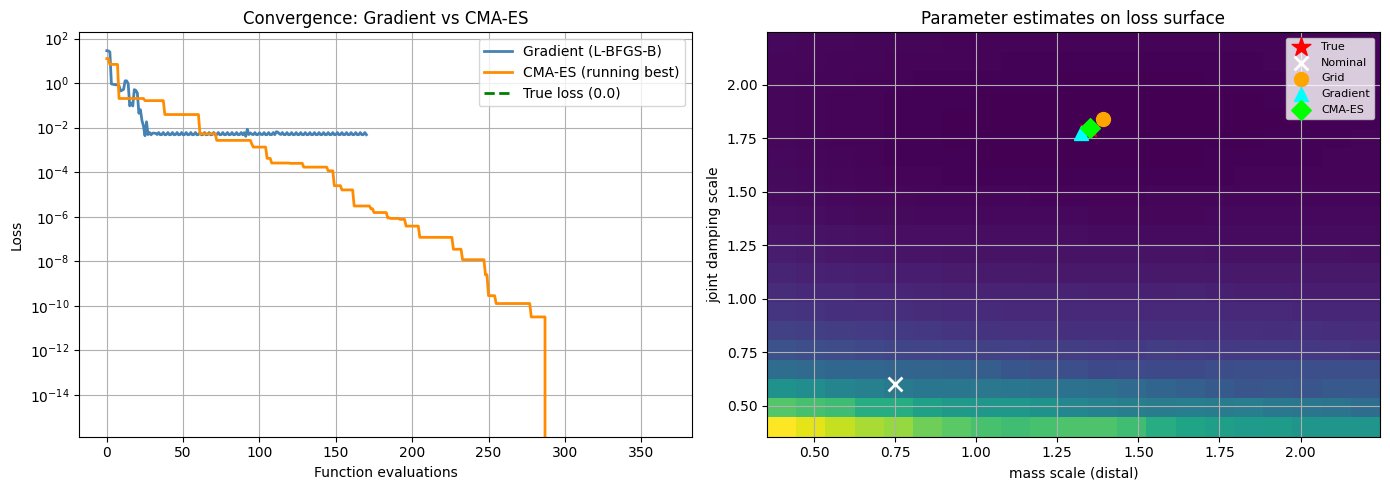

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss curves over function evaluations
axes[0].plot(info_grad['loss_history'], label='Gradient (L-BFGS-B)', color='steelblue')
axes[0].plot(
    # CMA-ES evaluates in batches — plot running best
    np.minimum.accumulate(info_cma['loss_history']),
    label='CMA-ES (running best)', color='darkorange'
)
axes[0].axhline(0, color='green', linestyle='--', label='True loss (0.0)')
axes[0].set_xlabel('Function evaluations')
axes[0].set_ylabel('Loss')
axes[0].set_title('Convergence: Gradient vs CMA-ES')
axes[0].legend()
axes[0].set_yscale('log')

# Right: parameter space — where each method ended up
M, D = np.meshgrid(mgrid, dgrid, indexing='ij')
axes[1].pcolormesh(M, D, L, shading='auto', cmap=cm.viridis)
axes[1].scatter(*THETA_TRUE,    c='red',    marker='*', s=200, label='True',     zorder=5)
axes[1].scatter(*THETA_NOMINAL, c='white',  marker='x', s=100, label='Nominal',  zorder=5)
axes[1].scatter(*theta_grid,    c='orange', marker='o', s=100, label='Grid',     zorder=5)
axes[1].scatter(*theta_grad,    c='cyan',   marker='^', s=100, label='Gradient', zorder=5)
axes[1].scatter(*theta_cma,     c='lime',   marker='D', s=100, label='CMA-ES',   zorder=5)
axes[1].set_xlabel('mass scale (distal)')
axes[1].set_ylabel('joint damping scale')
axes[1].set_title('Parameter estimates on loss surface')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. Reflection Questions
- Which method found better parameters?
- Which method required more function evaluations?
- Did lower train rollout error imply lower test rollout error?
- When might grid search outperform gradient-based optimization?
- Why is excitation important for SysID?

## 12. Extra Credit
Replace grid search with a more scalable sampling-based optimizer (e.g., CMA-ES, CEM, random-restart search) and compare against gradient-based SysID. Keep the same loss for fair comparison and discuss convergence/runtimes.